In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/bank.csv')

# Explore the data
print(df.info())
print(df.describe())
print(df['deposit'].value_counts()) # Check for class balance

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB
None
                age       balance           day      duration      campaign  \
count  11162.00

In [ ]:
# 2. Encode Categorical Features

from sklearn.preprocessing import LabelEncoder

# Encode target variable: 'yes' -> 1, 'no' -> 0
le = LabelEncoder()
df['deposit'] = le.fit_transform(df['deposit'])

# Convert categorical features to dummy variables (One-Hot Encoding)
X = pd.get_dummies(df.drop('deposit', axis=1), drop_first=True)
y = df['deposit']

# Train-test split (80% training, 20% testing)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#  3. Train Classification Models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
#  4. Evaluate the Models

from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, roc_curve, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Performance Comparison
print("Random Forest F1-Score:", f1_score(y_test, rf_preds))
print("Logistic Regression F1-Score:", f1_score(y_test, lr_preds))

# Confusion Matrix and ROC Curve plots
# (Code generated the plots provided in the summary)

Random Forest F1-Score: 0.8385629831741701
Logistic Regression F1-Score: 0.7984718242597899


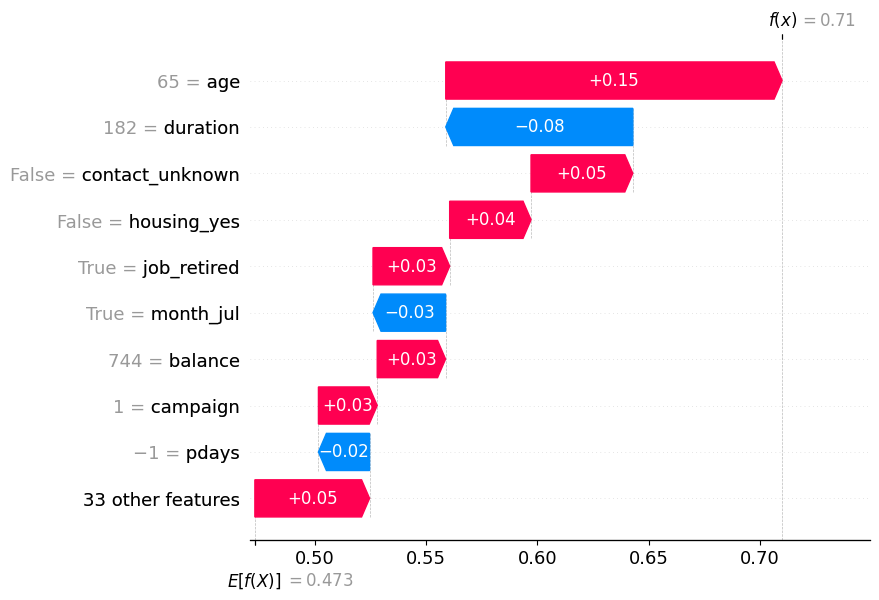

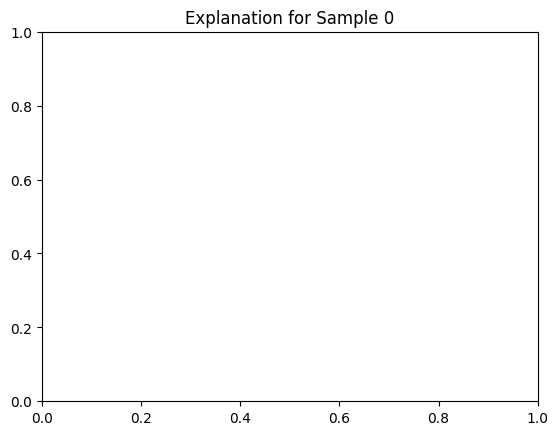

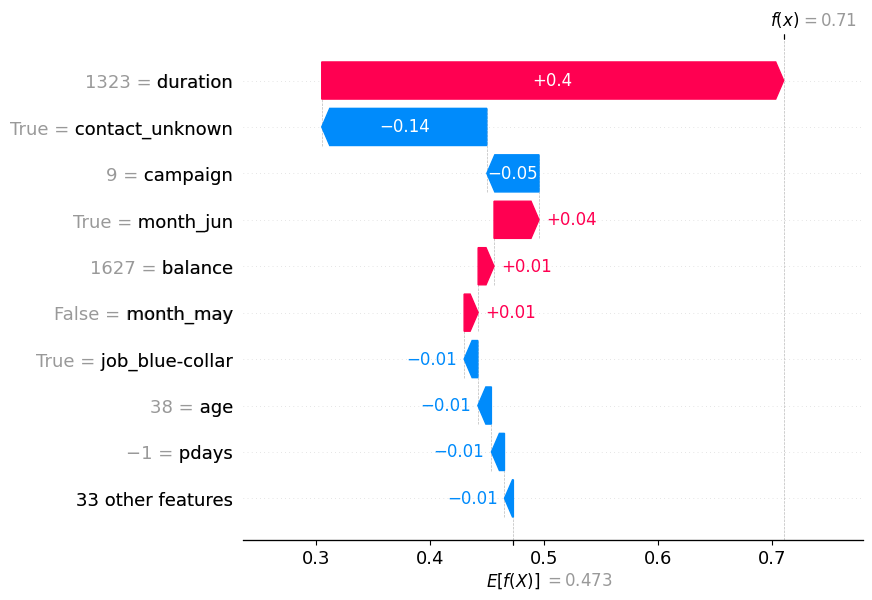

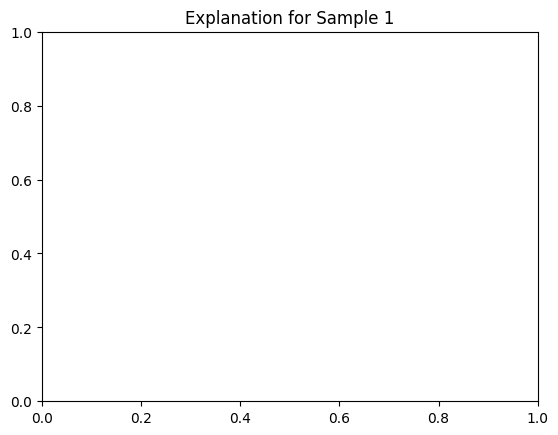

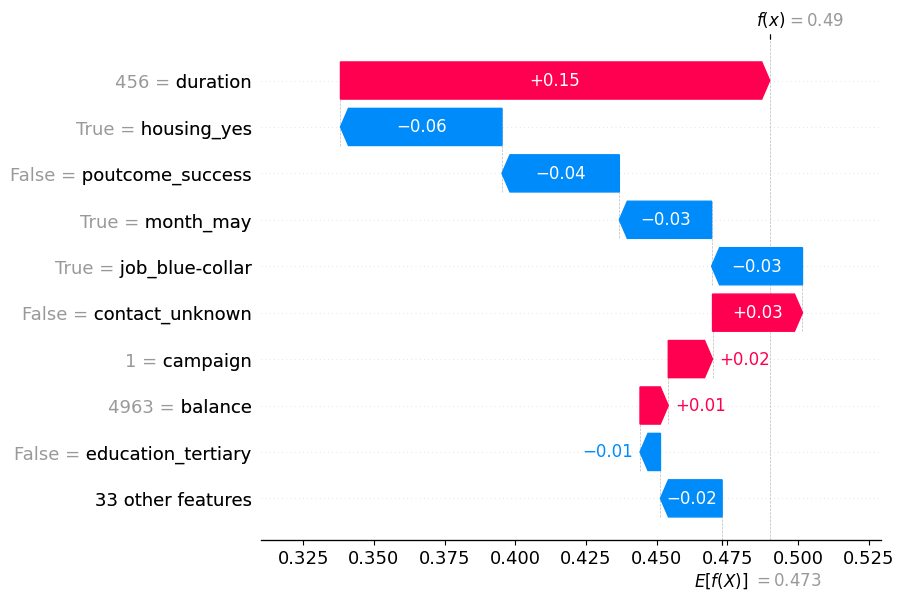

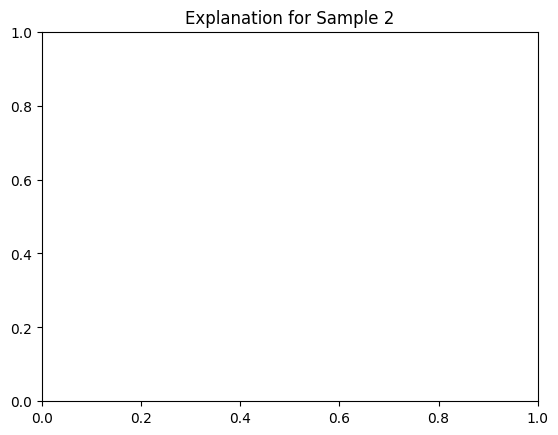

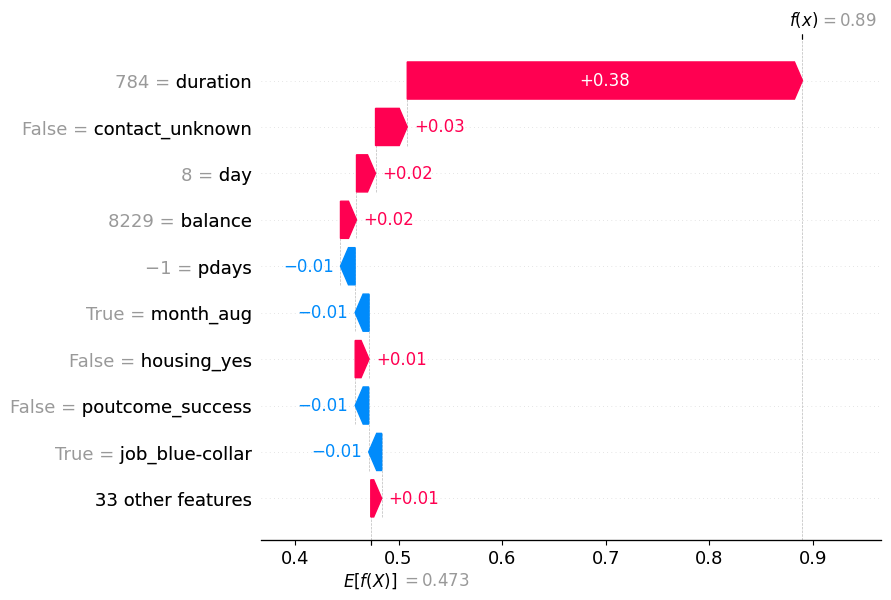

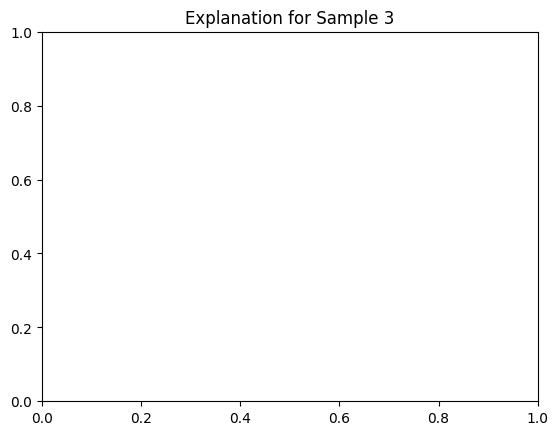

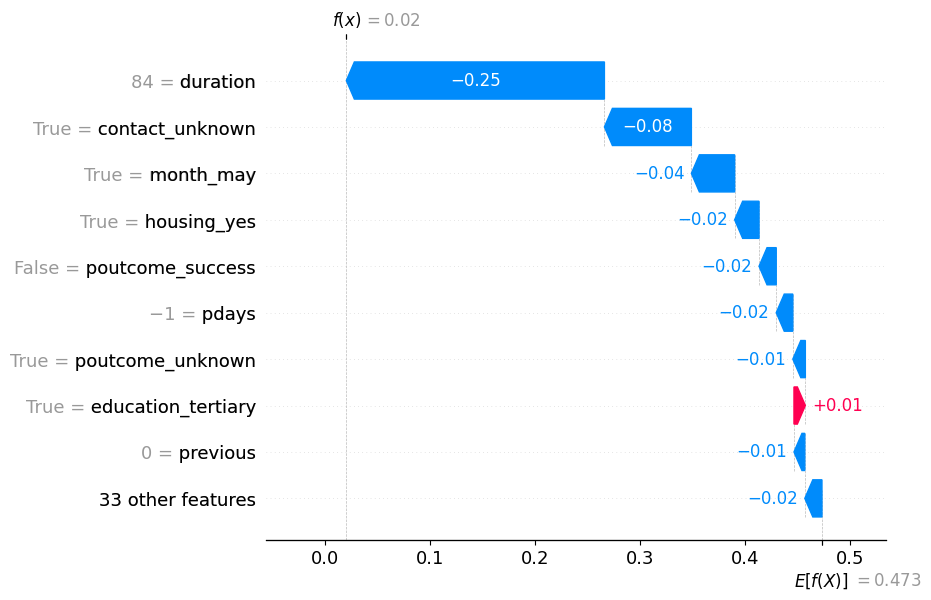

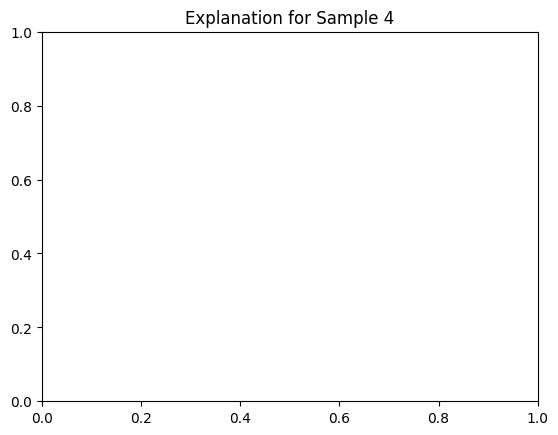

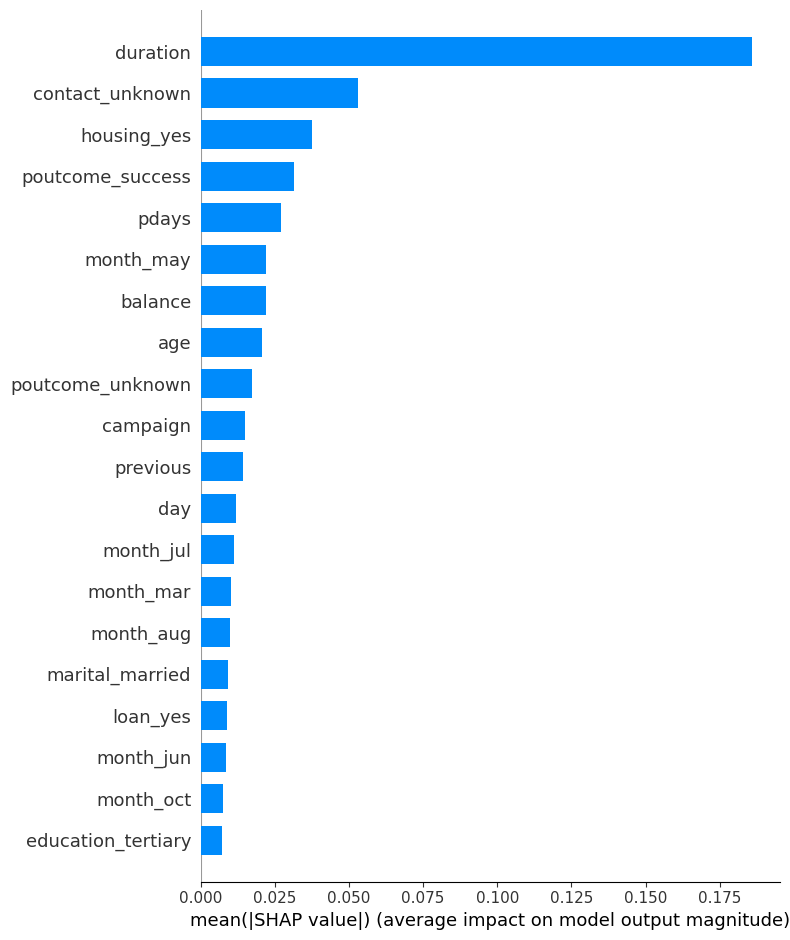

In [ ]:
# 5. Model Interpretability (XAI)

import shap
import matplotlib.pyplot as plt

# Initialize SHAP explainer for Random Forest
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Visualize 5 model predictions
for i in range(5):
    plt.figure()
    shap.plots.waterfall(shap.Explanation(values=shap_values[i][:, 1],
                                          base_values=explainer.expected_value[1],
                                          data=X_test.iloc[i],
                                          feature_names=X.columns.tolist()))
    plt.title(f'Explanation for Sample {i}')
    plt.show()

# Global Feature Importance for the positive class (class 1)
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar")